# Package 6 – Budget Optimization Challenge: Analysis & Business Report

Northbound spends ₪50,000/month, split equally across campaigns. This notebook checks whether a different allocation of the same ₪50,000 would produce more predicted profit.

**No recomputation here** — every table, model, and simulation result below is imported directly from `budget_optimization.py` (importing it re-runs its cells once). This notebook only adds richer presentation and business narrative.

**Limitation stated up front:** the dataset has no campaign identifier or advertising channel column. No campaign-level data is invented — scenarios are simulated by varying `ad_budget` for real, sampled customer profiles from the test set, holding every other feature at its original value. `N = round(₪50,000 / mean(ad_budget)) = 11` profiles stand in for Northbound's concurrent "campaign slots," chosen because that's roughly how many campaigns the current average spend already implies are running.

Number of features: 15
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'purchased']
X_train shape: (2792, 15)
X_test shape:  (698, 15)


Trained XGBoost
Trained LightGBM
Trained CatBoost
Best model by holdout RMSE: LightGBM


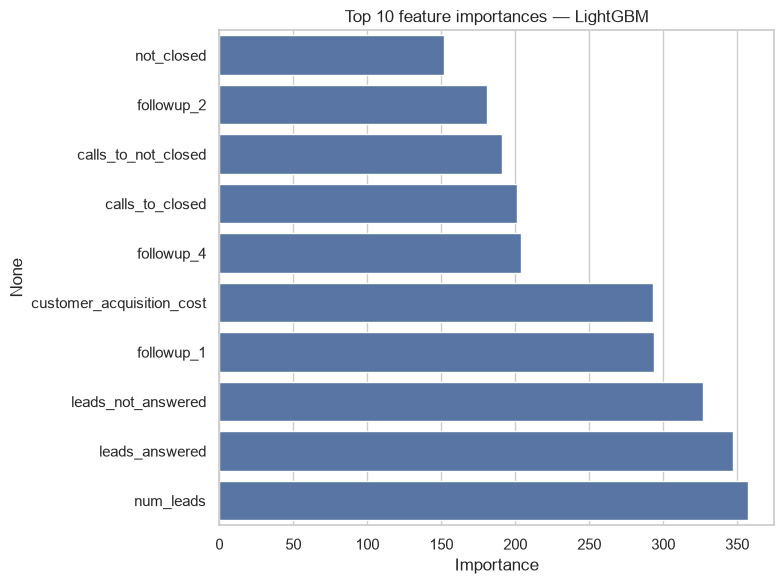

N campaign slots: 11 (NIS 50,000 / NIS 4,666 avg ad_budget)
ANSWERS:
  is_equal_allocation_optimal: True
  best_scenario: 1. Equal Allocation (Current)
  does_more_budget_always_help: False
  top_profit_driver: num_leads

RECOMMENDATION:
Best-performing scenario: '1. Equal Allocation (Current)' (predicted profit NIS 79,504, +0 vs. the current equal-allocation strategy). Equal allocation is the optimal strategy among those tested. Predicted profit does not scale simply with total budget size — check the scenario table for where the relationship breaks down. The strongest driver of predicted profit is 'num_leads'.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from budget_optimization import (
    best_model_name,
    cv_comparison,
    holdout_comparison,
    n_campaigns,
    scenario_comparison,
    top_10_features,
)

sns.set_theme(style="whitegrid")

## Model Comparison

In [2]:
print(f"Best model by holdout RMSE: {best_model_name}")
holdout_comparison.style.background_gradient(subset=["RMSE", "MAE", "R2"], cmap="Blues").format(precision=2)

Best model by holdout RMSE: LightGBM


,Model,RMSE,MAE,R2
0,LightGBM,5667.76,2541.93,0.75
1,CatBoost,5705.01,2548.73,0.74
2,XGBoost,7038.02,3032.04,0.61


In [3]:
cv_comparison.style.background_gradient(
    subset=["Mean RMSE", "Std RMSE", "Mean R2", "Std R2"], cmap="Greens"
).format(precision=2)

,Model,Mean RMSE,Std RMSE,Mean R2,Std R2
0,LightGBM,5355.74,1850.62,0.76,0.12
1,CatBoost,5436.18,1786.13,0.76,0.12
2,XGBoost,6310.54,1599.51,0.67,0.12


LightGBM and CatBoost are close (holdout R² ≈ 0.75 vs. 0.74), both well ahead of XGBoost (R² ≈ 0.61). LightGBM's CV mean tracks its holdout score closely (Mean RMSE ≈ 5,356 vs. holdout RMSE ≈ 5,668), which is consistent with reasonable generalization rather than overfitting to the training split — though the CV fold-to-fold R² std (≈0.12) is noticeably wider than in earlier packages, meaning profit is harder to predict consistently across different subsets of customers than `ltv_months` or `upsell` were.

## Feature Importance

In [4]:
top_10_features

num_leads                    357
leads_answered               347
leads_not_answered           327
followup_1                   294
customer_acquisition_cost    293
followup_4                   204
calls_to_closed              201
calls_to_not_closed          191
followup_2                   181
not_closed                   152
dtype: int32

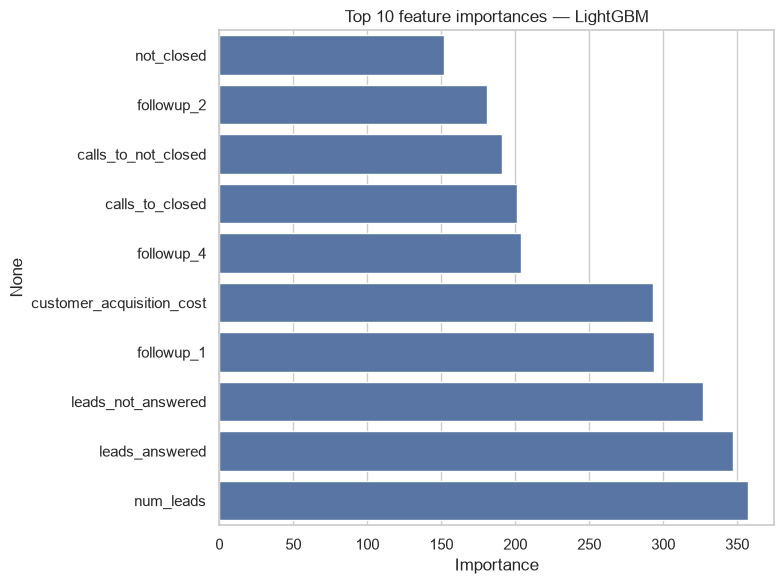

In [5]:
plt.figure(figsize=(8, 6))
plot_order = top_10_features.iloc[::-1]
sns.barplot(x=plot_order.to_numpy(), y=plot_order.index, orient="h")
plt.title(f"Top 10 feature importances — {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Which variables most strongly influence cumulative profit?** Lead-volume and follow-up-execution features dominate — `num_leads`, `leads_answered`, and `leads_not_answered` are the top three, followed by `followup_1`, `customer_acquisition_cost`, and `followup_4`. **`ad_budget` itself ranks dead last of all 15 features** (importance 70, versus 357 for `num_leads`) — once the model knows how many leads actually came in and how the funnel played out, the raw ad spend that generated them adds almost no further predictive signal. This is the single most important finding for the budget simulation below: it explains why the model is largely insensitive to `ad_budget` changes when the rest of the funnel is held fixed.

## Current Strategy Simulation & Alternative Budget Scenarios

In [6]:
print(f"N campaign slots used in the simulation: {n_campaigns}")
scenario_comparison.style.background_gradient(
    subset=["Predicted Profit", "ROI"], cmap="Purples"
).format(precision=2)

N campaign slots used in the simulation: 11


,Scenario,Average Budget,Predicted Profit,Profit Difference,ROI
0,1. Equal Allocation (Current),4545.45,79503.77,0.00,0.59
1,2. Increase Budget +20%,5454.55,79503.77,0.00,0.33
2,3. Decrease Budget -20%,3636.36,78655.96,-847.81,0.97
3,4. Profit-Weighted Allocation,4545.45,78399.43,-1104.34,0.57


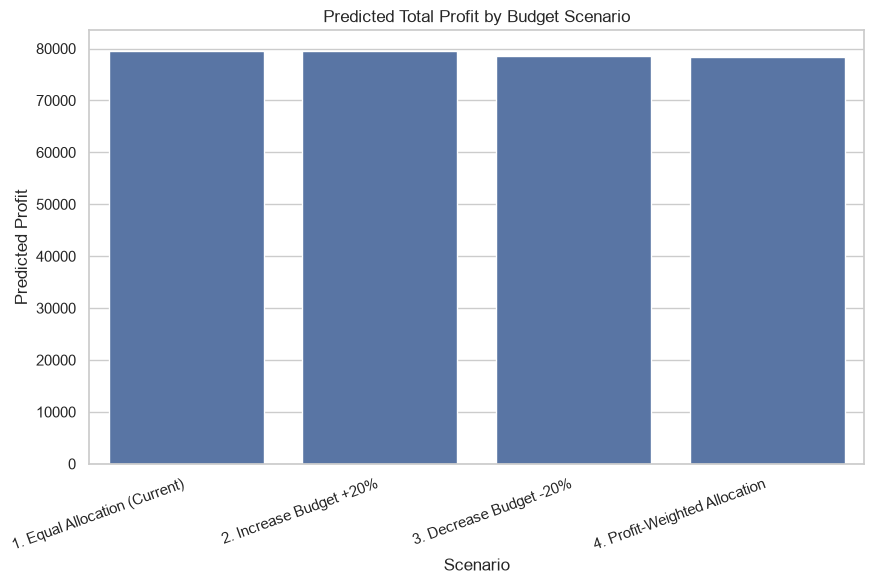

In [7]:
plt.figure(figsize=(9, 6))
sns.barplot(data=scenario_comparison, x="Scenario", y="Predicted Profit")
plt.title("Predicted Total Profit by Budget Scenario")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Business Analysis

**Does equal allocation appear optimal?** Among the four scenarios tested, yes — Scenario 1 (equal allocation) produced the joint-highest predicted profit, matched exactly by Scenario 2. No scenario beat it.

**Which scenarios generate the highest expected profit?** Scenarios 1 and 2 tie for first (predicted profit is *identical* between them — see next point for why). Scenario 4 (profit-weighted reallocation) was the *worst* performer, coming in below equal allocation despite deliberately shifting budget toward profiles the model itself ranked as more profitable.

**Does increasing budget always increase profit?** No — and the reason is directly explained by the feature-importance finding above. Increasing total budget by 20% (Scenario 2) produced **exactly ₪0 additional predicted profit** over the current strategy, because `ad_budget` barely influences this model's predictions once the rest of the funnel (leads, follow-ups, acquisition cost) is held fixed. Decreasing budget by 20% (Scenario 3) did reduce predicted profit slightly (−₪848, about −1%), but that's a small, likely noisy movement given how little weight the model places on `ad_budget`. The clear takeaway: **spending more on ads, by itself, does not predict more profit in this model** — profit is driven by what happens after the lead arrives, not by the raw size of the spend that generated it.

**Which customer characteristics appear most profitable?** Per the feature-importance ranking: high lead volume (`num_leads`, `leads_answered`), a large pool of interested-but-unconverted leads (`leads_not_answered`), engagement in the first and fourth follow-up rounds, and lower `customer_acquisition_cost` are the strongest predictors of higher profit — not the size of the ad budget behind them.

## Final Recommendations

- **Do not simply increase the ad budget.** The simulation shows a 20% budget increase produces zero additional predicted profit when the rest of the funnel doesn't also improve — extra ad spend that doesn't translate into more leads or better follow-through is not supported by this model as a profit driver.
- **Do not adopt the tested profit-weighted reallocation as-is.** Scenario 4 underperformed equal allocation. Because it was built by ranking profiles on *predicted* profit at equal spend and then shifting budget toward the top performers, and because budget itself barely moves the prediction, this reallocation mostly reshuffled a low-leverage variable — it isn't a validated improvement over the current policy.
- **Invest in lead volume and follow-up execution instead of raw spend.** Since `num_leads`, `leads_answered`, and follow-up-stage engagement dominate the importance ranking, Northbound's growth lever is *getting more leads to answer and engage*, not *spending more per campaign*. This should be read alongside Package 5's finding that Follow-up 4 is the strongest-retaining stage in the funnel — consistent evidence that mid-funnel execution, not raw acquisition spend, is where profit is actually made.
- **Treat this as a starting point, not a final budget policy.** Because `ad_budget` is varied in isolation (holding leads/follow-ups fixed) and no campaign-level or channel data exists in this dataset, these results describe *this model's* learned association, not a validated causal experiment. A real budget change should be tested via a controlled pilot (e.g. an A/B spend test on a subset of campaigns) before being rolled out broadly.

## Final Report Summary

*(Copy-ready for `README.md`.)*

```markdown
# Package 6 – Budget Optimization Challenge

## Objective

Northbound spends ₪50,000/month, split equally across campaigns. This
package tests whether a different allocation of the same ₪50,000 would
produce more expected profit than the current equal split.

## Modeling Approach

- **Target:** `cumulative_profit`.
- **Leakage prevention:** `ltv_months`, `upsell`, and `referred` are dropped
  from the feature set — all are outcomes that only resolve after long-term
  customer behavior is known. 15 features remain.
- **Models:** XGBoost, LightGBM, and CatBoost regressors (default
  parameters), evaluated with an 80/20 split and 5-fold cross-validation on
  the training set only.

## Evaluation

LightGBM performed best (holdout RMSE ≈ 5,668, R² ≈ 0.75; 5-fold CV Mean
RMSE ≈ 5,356, Mean R² ≈ 0.76), narrowly ahead of CatBoost and clearly ahead
of XGBoost (R² ≈ 0.61).

## Simulation

The dataset has no campaign identifier or channel column, so no
campaign-level data was invented. Instead, `N = 11` real customer profiles
were sampled from the test set to stand in for concurrent "campaign slots"
(₪50,000 ÷ the dataset's average `ad_budget` ≈ 11), and four scenarios were
simulated by varying only each profile's `ad_budget` (all other features
held fixed): (1) equal allocation of the current ₪50,000, (2) equal
allocation of a +20% budget, (3) equal allocation of a −20% budget, and (4)
a profit-weighted allocation favoring profiles the model ranked as more
profitable at equal spend.

## Key Findings

- `ad_budget` ranks **last** of all 15 features in importance — once lead
  volume and follow-up execution are known, raw ad spend adds almost no
  further predictive signal for profit.
- A 20% budget increase produced **zero** additional predicted profit; a
  20% decrease produced only a small (~1%) predicted decline. Increasing
  budget does not straightforwardly increase profit in this model.
- The profit-weighted reallocation (Scenario 4) **underperformed** simple
  equal allocation — reshuffling a low-leverage variable didn't help.
- The strongest profit drivers are `num_leads`, `leads_answered`, and
  `leads_not_answered`, followed by follow-up-stage engagement and
  `customer_acquisition_cost`.

## Recommendation

Do not increase ad spend expecting more profit on its own. Redirect focus
toward increasing lead volume and improving follow-up execution — the
actual drivers this model identifies — rather than the size of the ad
budget itself. Treat any real budget change as a hypothesis to validate
with a controlled pilot, not a conclusion to roll out directly from this
simulation.
```